# KNN Project
## Group Members:
- **Benjamin Nelson**: Wrote the bulk of the code for our KNN algorithm
- **Cole Clodgo**: Wrote the markdown explanations
- **Kaiden McCready**: Handled getting the datasets in and doing preprocessing of the data
- **Kosei Yamaguchi**: Ran experiments and tested the code
## Project Explanation
K Nearest Neighbors is a machine learning algorithm that classifies data points based on the labels of nearby points. Our algorithm takes data points, an unlabeled point, and a value for k as inputs. It then computes the distance between the unlabeled point and every labeled data point. We then look at the k points that are closest to the unlabeled point, and whichever label has a simple majority is assigned to the unlabeled point.
## Data
We run our KNN algorithm on two different datasets. These datasets allow us to test our algorithm using real data with different dimensions. 
### Fisher Iris Data
The first dataset is the Fisher Iris Data set. This dataset contains 150 samples of iris flowers. These samples are categorized into 4 species and have 4 numeric attributes. We use these attributes to categorize an unlabeled sample into one of the four species by using the numeric values for the attributes to find the "distance" between the samples. We then categorize the new sample by using the other samples' species as their labels.

In [ ]:
# ***
# Prerequisites:
# pip install ucimlrepo
# ***

from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# from 'cleanup.ipynb'
mpg_training_set = pd.read_csv("auto-mpg_training_data.csv").to_numpy()

def adapt_for_bens_LoL(numpy_array):
    n_parameters = len(numpy_array[0]) - 1
    # magic box that turns [[5], ...] into [[[4], [1]], ...]. probably slow when working with big datasets.
    return [[row[:n_parameters].tolist(), row[n_parameters]] for row in numpy_array] 

mpg_training_set = adapt_for_bens_LoL(mpg_training_set)
print(mpg_training_set)


In [ ]:
import math

"""
Inputs: data = [[[values],valueToFind],[[values1],valueToFind1],...], pointToFind = [value1, value2, ...], k = int
Outputs: retValue = value for pointToFind based on the average valueToFind of the k nearest neighbors in data
----------------------------------------
First it run through all the points and only holds on to the k closest points to the pointToFind. 
If a point is closer than another it replaces it in Closest. 
Then it calculates the weight of each point based on how close it is to the pointToFind.
Finally it applies the weights to the valuesToFind to get the better true average value for the pointToFind.

Note: You can set Unweighted = True to ignore the weights and just use the average of the k closest points.
"""


def KNN(data, pointToFind, k, Unweighted = False):
  #find Closests
  #closest[0] = dist, [1] = value, [2] = valueToFind, [3] = weight
  
  Closest = {"Dist": [], "Value": [], "valueToFind": [], "Weight": []}
  for Point in data:
    dist = 0
    for variableId in range(len(Point[0])):
      dist += ((pointToFind[variableId]-Point[0][variableId])**2)
    dist = math.sqrt(dist)
    
    #add to Closest
    if len(Closest["Dist"]) >= k:
      compareItem = max(Closest["Dist"])
      if compareItem > dist:
        #get indexs and choose the first one
        index = Closest["Dist"].index(compareItem)
        Closest["Dist"][index] = dist
        Closest["Value"][index] = Point[0]
        Closest["valueToFind"][index] = Point[1]
        Closest["Weight"][index] = 1.0  
        #Weight equels 1 by defult because this will be multiplied later on. 
        # If unweighted it will use 1 rather than another calculation.
    else:
      Closest["Dist"].append(dist)
      Closest["Value"].append(Point[0])
      Closest["valueToFind"].append(Point[1])
      Closest["Weight"].append(1.0)

  if not Unweighted:
    TotalWeight = 0 #Total weight will be used to standardize the weights so that they sum to 1.0. 

    for itemIndex in range(len(Closest["Dist"])):

      #weighting by the inverse of the distance. 
      value = 1 - Closest["Dist"][itemIndex]
      Closest["Weight"][itemIndex] = value
      TotalWeight += value

    for itemIndex in range(len(Closest["Dist"])):
      Closest["Weight"][itemIndex] = Closest["Weight"][itemIndex]/TotalWeight
  #Standardizing the weight so that they are even. This will make sure the result isn't just the sum but the average.
  else:
    for itemIndex in range(len(Closest["Dist"])):
      Closest["Weight"][itemIndex] = 1/k

  #calculate the average valueToFind from the k closest points and return it in retValue
  retValue = 0

  for itemIndex in range(len(Closest["valueToFind"])):
    retValue += Closest["valueToFind"][itemIndex] * Closest["Weight"][itemIndex]
  
  return retValue

In [ ]:
#Test to make sure KNN works on a basic input.
data = [[[8.0,27.0,0.0,9.4],5],[[89.0,27.0,1.0,69.4],3],[[87.0,27.0,0.0,97.4],5],[[90.0,90.0,3.0,25.4],3],[[95.0,23.0,3.0,80.4], 5]]
point = [105.0,90.0,2.0,85.4]

KNN(data, point, 3)

3.682183787524911

In [2]:

# # [-1.3807270877331406,0.3367202847780191,-1.3934698549528162,-1.3085928194379575] -> Iris-setosa as a test case.
# iris_test_point = [-1.3807270877331406,0.3367202847780191,-1.3934698549528162,-1.3085928194379575]
# KNN(data=iris_training_set, pointToFind=iris_test_point, k=3)
# [0.2,0.007751937984496124,0.10326086956521739,0.04536433229373405,0.6547619047619048,0.08333333333333333,31.0] -> 18.0 mpg as a test case
mpg_test_point = [0.2,0.007751937984496124,0.10326086956521739,0.04536433229373405,0.6547619047619048,0.08333333333333333,31.0]
KNN(data=mpg_training_set, pointToFind=mpg_test_point, k=3, Unweighted=False)




NameError: name 'mpg_training_set' is not defined

In [ ]:
mpg_evaluating_set = pd.read_csv("auto-mpg_testing_data.csv")

# format test points to ben's LoL
eval_points = mpg_evaluating_set.drop(columns="mpg").values.tolist()
print(eval_points)

# evaluate k options + accuracies
evaluations = pd.DataFrame(columns=["unweighted", "k", "mse"])

for evaltype in [True, False]:
    # check k 1 - 75
    for k in range(1, 76):    
        print(f"k = {k}")
        # run the model on each point in the test set (eval_points)
        mpg_evaluating_set["Predicted"] = [KNN(mpg_training_set, point, k, Unweighted=evaltype) for point in eval_points]
        # check to see if each prediction was correct
        mpg_evaluating_set["Squared Error"] = (mpg_evaluating_set["mpg"] - mpg_evaluating_set["Predicted"]) ** 2
        print(mpg_evaluating_set["Squared Error"])
        # get the % of accurate predictions
        mse = mpg_evaluating_set["Squared Error"].mean()
        evaluations = pd.concat([evaluations, pd.DataFrame([{'unweighted': evaltype, 'k': k, 'mse': mse}])], ignore_index=True)
        # print(f"k = {k}; accuracy = {accuracy.round(5)}")

[[1.0, 0.6175710594315246, 0.4565217391304347, 0.5361497022965693, 0.238095238095238, 0.0], [1.0, 0.9974160206718348, 0.9456521739130436, 0.7771477176070315, 0.0595238095238095, 0.0], [1.0, 1.0, 0.9728260869565216, 0.4176353841791891, 0.119047619047619, 0.0], [0.2, 0.1162790697674418, 0.266304347826087, 0.2151970513184009, 0.4166666666666666, 0.0], [0.2, 0.0749354005167958, 0.2282608695652173, 0.1465834987241281, 0.3869047619047618, 0.0], [0.2, 0.0749354005167958, 0.0, 0.062943011057556, 0.7440476190476191, 0.0], [0.2, 0.1369509043927648, 0.3641304347826087, 0.1760703147150553, 0.2678571428571428, 0.0], [0.6, 0.3385012919896641, 0.2391304347826087, 0.2934505245250921, 0.4166666666666666, 0.0], [1.0, 0.6175710594315246, 0.8369565217391305, 0.7833853132974199, 0.4166666666666666, 0.0], [1.0, 0.6098191214470284, 0.7989130434782609, 0.8843209526509782, 0.625, 0.0], [0.2, 0.1860465116279069, 0.2391304347826087, 0.1845761270201304, 0.4464285714285714, 0.0833333333333333], [0.6, 0.47028423772

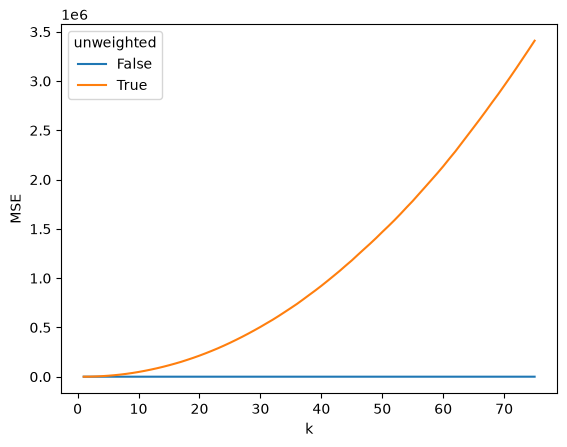

In [21]:
_ = sns.lineplot(data=evaluations, x="k", y="mse", hue="unweighted")
plt.xlabel('k')
plt.ylabel('MSE')
plt.show()